# ROP Baseline Classifier — Standardized Multi-Backbone Notebook
One notebook, five fair baselines: **ResNet18, DenseNet121, EfficientNetV2-S, ConvNeXt-Tiny, GhostNetV2**.
Everything is identical across models — dataset indexing, preprocessing, augmentation, stratified
split, seed, image size, batch size, optimizer, LR, epochs, checkpointing, evaluation, camera-wise
(Neo/RetCam) evaluation, confusion matrix, ROC/PR curves, Grad-CAM, and results export. **Only the
backbone changes.**

To run a baseline: set `Config.MODEL_KEY` in Cell 3 (the `BACKBONE` string resolves automatically
from the verified `MODEL_REGISTRY`), then Run All. Repeat for each of the 5 keys. After all 5 have
been trained, run the final **Cross-Model Comparison** section to get the master table.

Sections: Imports -> Config -> Dataset -> Preprocessing -> Augmentation -> DataLoader -> Model ->
LightningModule -> Trainer -> Training -> Load Best Checkpoint -> Evaluation -> Threshold Sweep ->
Metrics -> Confusion Matrix -> ROC/PR Curve -> Grad-CAM -> External Demo -> Cross-Model Comparison

## Section 1 — Imports

In [3]:
# Cell 1: One-time installs (run once per fresh session)
!pip install -q timm pytorch-lightning torchmetrics seaborn scikit-learn thop opencv-python-headless "numpy<2"

In [4]:
# Cell 2: Imports
import os, random, time, json
import numpy as np
import pandas as pd
import cv2

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score, confusion_matrix,
    roc_curve, precision_recall_curve, balanced_accuracy_score,
    matthews_corrcoef, cohen_kappa_score,
    accuracy_score, precision_score, recall_score, f1_score,
)

import timm
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger

from torchvision import transforms
from PIL import Image

from torchmetrics.classification import (
    BinaryPrecision, BinaryRecall, BinaryF1Score, BinaryAccuracy
)

import matplotlib.pyplot as plt
import seaborn as sns

## Section 2 — Config

In [5]:
# Cell 3: MODEL REGISTRY - verified timm identifiers only.
# Every entry below was confirmed to exist in the installed timm build (timm.list_models(...,
# pretrained=True)) AND confirmed to support backbone(x) / forward_features() / forward_head()
# with num_classes=0, which is what ROPModel and Grad-CAM rely on. Do not substitute unverified
# names - timm silently raises RuntimeError on a wrong string, it does not fuzzy-match.
#
# All five are the "plain in1k" pretrained variant of their family (no in21k pretraining, no
# extra-recipe suffixes) so the pretraining data is comparable across baselines:
MODEL_REGISTRY = {       # official FAIR ImageNet-1k weights (not in22k-ft)
    "ghostnetv2":"ghostnetv2_100.in1k",         # your current working config, unchanged
}

# Cell 3: CONFIG - single source of truth for the whole notebook
class Config:
    # ---- Paths ----
    DATA_ROOT = "/teamspace/studios/this_studio/HVDROPDB_RetCam_Neo_Classification"
    RESULTS_ROOT = "results"

    # ---- Model identity ----
    # >>> THE ONLY LINE YOU NEED TO CHANGE TO SWITCH BASELINE <<<
    MODEL_KEY = "ghostnetv2"                # one of: resnet18 | densenet121 | efficientnetv2_s | convnext_tiny | ghostnetv2
    BACKBONE  = MODEL_REGISTRY[MODEL_KEY]   # auto-resolved from MODEL_REGISTRY - never hand-type this

    # ---- Reproducibility ----
    SEED = 42

    # ---- Data ----
    IMG_SIZE = 256                          # per preprocessing spec: resize to 256x256 - identical for all 5 models
    BATCH_SIZE = 8
    NUM_WORKERS = 2
    VAL_FRAC = 0.15
    TEST_FRAC = 0.15

    # ---- Model ----
    PRETRAINED = True
    NUM_CLASSES = 1                         # binary head -> BCEWithLogitsLoss

    # ---- Training ----
    LR = 1e-5
    MAX_EPOCHS = 30

    # ---- Class mapping ----
    LABEL_MAP = {"Normal": 0, "ROP": 1}

    # ---- Decision threshold - THE ONLY THRESHOLD IN THE ENTIRE NOTEBOOK ----
    # Used identically by: validation, testing, confusion matrix, external
    # inference, and Grad-CAM. Change this ONE value to change every
    # prediction downstream - never hardcode a threshold anywhere else.
    THRESHOLD = 0.5

    # ---- ROP risk banding (external inference report only) ----
    RISK_BANDS = [
        (0.00, 0.30, "Low"),
        (0.30, 0.50, "Borderline"),
        (0.50, 0.75, "Moderate"),
        (0.75, 1.01, "High"),
    ]

assert Config.MODEL_KEY in MODEL_REGISTRY, (
    f"Unknown MODEL_KEY '{Config.MODEL_KEY}'. Valid keys: {list(MODEL_REGISTRY.keys())}"
)
print(f"MODEL_KEY = {Config.MODEL_KEY}  ->  BACKBONE = {Config.BACKBONE}")

MODEL_KEY = ghostnetv2  ->  BACKBONE = ghostnetv2_100.in1k


## Section 3 — Dataset

In [6]:
# Cell 4: Seed + GPU detection + output folders
def set_seed(seed=Config.SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
else:
    print("No GPU attached to this session - check compute type before training.")

MODEL_DIR = os.path.join(Config.RESULTS_ROOT, Config.MODEL_KEY)
os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(os.path.join(MODEL_DIR, "figures"), exist_ok=True)
print(f"Outputs will be saved to: {MODEL_DIR}/")

Device: cuda
GPU: Tesla T4
Outputs will be saved to: results/ghostnetv2/


In [7]:
# Cell 5: Build file index - walk Normal/{Neo_Normal,RetCam_Normal} and ROP/{Neo_ROP,RetCam_ROP}
def build_index(data_root):
    records = []
    if not os.path.exists(data_root):
        raise FileNotFoundError(f"DATA_ROOT does not exist: {data_root}")
    for cls_name, label in Config.LABEL_MAP.items():
        cls_dir = os.path.join(data_root, cls_name)
        if not os.path.isdir(cls_dir):
            raise FileNotFoundError(f"Missing class folder: {cls_dir}")
        camera_subdirs = [d for d in os.listdir(cls_dir) if os.path.isdir(os.path.join(cls_dir, d))]
        if not camera_subdirs:
            raise FileNotFoundError(f"No camera subfolders found inside: {cls_dir}")
        for camera_subdir in camera_subdirs:
            camera = "Neo" if camera_subdir.startswith("Neo") else "RetCam"
            sub_path = os.path.join(cls_dir, camera_subdir)
            n_before = len(records)
            for fname in os.listdir(sub_path):
                if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    records.append({"filepath": os.path.join(sub_path, fname),
                                     "label": label, "class_name": cls_name, "camera": camera})
            print(f"{cls_name}/{camera_subdir}: {len(records) - n_before} images")
    if not records:
        raise ValueError("No images found - check file extensions or folder structure.")
    return pd.DataFrame(records)

df = build_index(Config.DATA_ROOT)
print(f"\nTotal images: {len(df)}")
df.groupby(["class_name", "camera"]).size()

Normal/Neo_Normal: 50 images
Normal/RetCam_Normal: 50 images
ROP/RetCam_ROP: 50 images
ROP/Neo_ROP: 35 images

Total images: 185


class_name  camera
Normal      Neo       50
            RetCam    50
ROP         Neo       35
            RetCam    50
dtype: int64

In [6]:
# Cell 6: Stratified 70/15/15 split by class AND camera
df["strata"] = df["class_name"] + "_" + df["camera"]

train_df, temp_df = train_test_split(
    df, test_size=(Config.VAL_FRAC + Config.TEST_FRAC),
    stratify=df["strata"], random_state=Config.SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=Config.TEST_FRAC / (Config.VAL_FRAC + Config.TEST_FRAC),
    stratify=temp_df["strata"], random_state=Config.SEED
)
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Train: 129 | Val: 28 | Test: 28


## Section 4 — Preprocessing

In [8]:
# Cell 7: Retinal preprocessing pipeline
# Order (matches spec exactly): Remove Black Border -> Circular Retina Crop
# -> CLAHE -> Gamma Correction. (Resize / Normalize / Augment happen later,
# in the torchvision transforms - see Section 5.)

def remove_black_border(img_np, threshold=10):
    """Crops away the black background/letterboxing around the fundus image."""
    gray = cv2.cvtColor(img_np, cv2.COLOR_RGB2GRAY)
    mask = gray > threshold
    if mask.sum() == 0:
        return img_np  # fallback: fully dark image, leave unchanged
    coords = np.argwhere(mask)
    y0, x0 = coords.min(axis=0)
    y1, x1 = coords.max(axis=0) + 1
    return img_np[y0:y1, x0:x1]

def circular_crop(img_np):
    """Masks the border-removed image down to the circular fundus region."""
    h, w = img_np.shape[:2]
    center = (w // 2, h // 2)
    radius = min(center)
    circ_mask = np.zeros((h, w), dtype=np.uint8)
    cv2.circle(circ_mask, center, radius, 255, -1)
    return cv2.bitwise_and(img_np, img_np, mask=circ_mask)

def apply_clahe(img_np, clip_limit=2.0, tile_grid_size=(8, 8)):
    """CLAHE on the L channel of LAB space - boosts local contrast without distorting color."""
    lab = cv2.cvtColor(img_np, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=tile_grid_size)
    l_eq = clahe.apply(l)
    lab_eq = cv2.merge((l_eq, a, b))
    return cv2.cvtColor(lab_eq, cv2.COLOR_LAB2RGB)

def gamma_correction(img_np, gamma=1.2):
    """gamma > 1 brightens midtones, gamma < 1 darkens them."""
    inv_gamma = 1.0 / gamma
    table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in range(256)]).astype("uint8")
    return cv2.LUT(img_np, table)

def preprocess_retinal_image(img_pil, use_border_removal=True, use_circular_crop=True,
                              use_clahe=True, use_gamma=True, gamma_value=1.2):
    """
    Full pipeline, PIL in -> PIL out:
    Remove Black Border -> Circular Retina Crop -> CLAHE -> Gamma Correction
    """
    img_np = np.array(img_pil.convert("RGB"))
    if use_border_removal:
        img_np = remove_black_border(img_np)
    if use_circular_crop:
        img_np = circular_crop(img_np)
    if use_clahe:
        img_np = apply_clahe(img_np)
    if use_gamma:
        img_np = gamma_correction(img_np, gamma=gamma_value)
    return Image.fromarray(img_np)

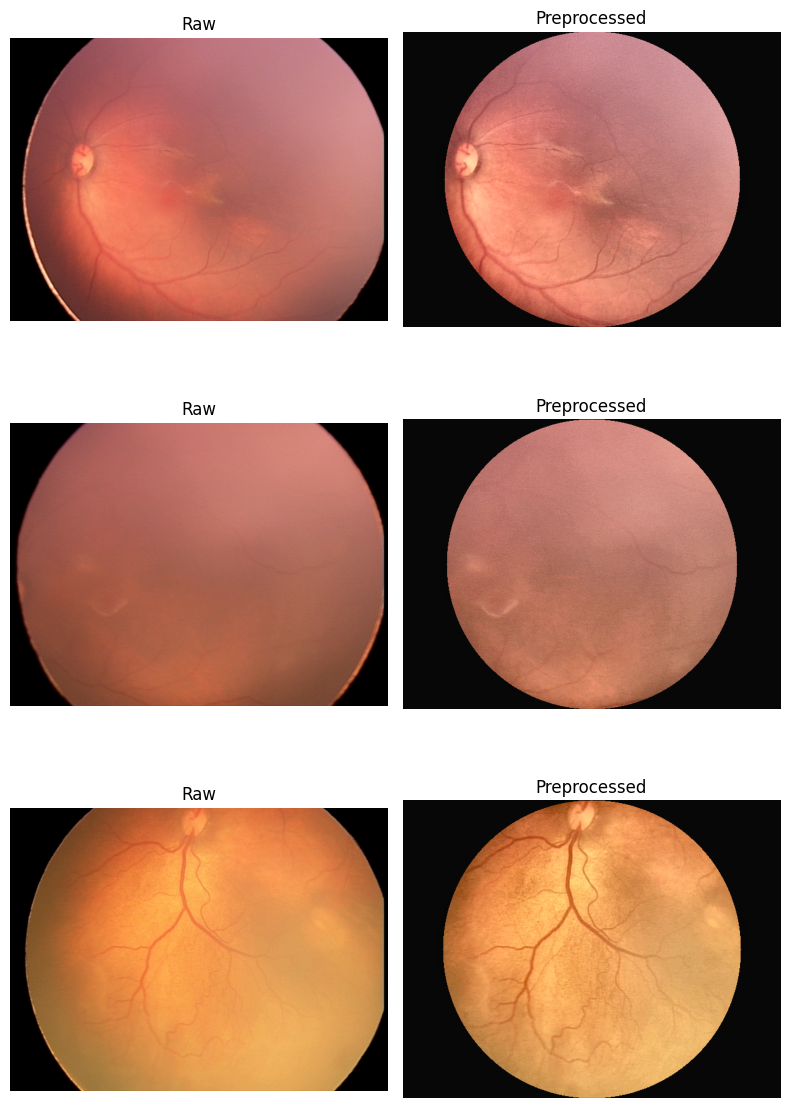

In [8]:
# Cell 8: Visual sanity check - raw vs preprocessed, on 3 sample images
fig, axes = plt.subplots(3, 2, figsize=(8, 12))
sample_rows = df.sample(3, random_state=Config.SEED)
for i, (_, row) in enumerate(sample_rows.iterrows()):
    raw = Image.open(row["filepath"]).convert("RGB")
    processed = preprocess_retinal_image(raw)
    axes[i, 0].imshow(raw); axes[i, 0].set_title("Raw"); axes[i, 0].axis("off")
    axes[i, 1].imshow(processed); axes[i, 1].set_title("Preprocessed"); axes[i, 1].axis("off")
plt.tight_layout()
plt.show()

## Section 5 — Augmentation

In [9]:

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.RandomResizedCrop(Config.IMG_SIZE, scale=(0.85, 1.0)),  # augmentation - train only
    transforms.RandomHorizontalFlip(),                                  # augmentation - train only
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tf = transforms.Compose([
    transforms.Resize((Config.IMG_SIZE, Config.IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

## Section 6 — DataLoader

In [10]:

class ROPDataset(Dataset):
    def __init__(self, dataframe, transform=None, preprocess=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.preprocess = preprocess

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["filepath"]).convert("RGB")
        if self.preprocess:
            img = preprocess_retinal_image(img)   
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(row["label"], dtype=torch.float32)

train_ds = ROPDataset(train_df, train_tf)
val_ds   = ROPDataset(val_df, eval_tf)
test_ds  = ROPDataset(test_df, eval_tf)

train_loader = DataLoader(train_ds, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS)
val_loader   = DataLoader(val_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)
test_loader  = DataLoader(test_ds, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS)

NameError: name 'train_df' is not defined

## Section 7 — Model

In [11]:

class ROPModel(nn.Module):
    """
    Generic timm backbone + a small MLP head for binary ROP vs Normal classification.
    Feature dimension is probed with a dummy forward pass rather than trusted from
    backbone.num_features, because some architectures (e.g. GhostNetV2) report that
    attribute incorrectly relative to what forward(x) actually returns.
    """
    def __init__(self, backbone_name=Config.BACKBONE, pretrained=Config.PRETRAINED):
        super().__init__()
        self.backbone = timm.create_model(backbone_name, pretrained=pretrained, num_classes=0)
        with torch.no_grad():
            dummy = torch.randn(1, 3, Config.IMG_SIZE, Config.IMG_SIZE)
            feat_dim = self.backbone(dummy).shape[1]
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128, Config.NUM_CLASSES),
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats).squeeze(1)   

## Section 8 — LightningModule

In [12]:
# Cell 12: Single LightningModule - used identically by training, checkpoint
# loading, evaluation, and inference. This is the only pl.LightningModule
# in the notebook, and it is architecture-agnostic (backbone_name is a parameter).
class ROPClassifier(pl.LightningModule):
    def __init__(self, backbone_name=Config.BACKBONE, lr=Config.LR, threshold=Config.THRESHOLD):
        super().__init__()
        self.save_hyperparameters()
        self.model = ROPModel(backbone_name)
        self.criterion = nn.BCEWithLogitsLoss()   # binary classification -> logits + BCE-with-logits

        for split in ["train", "val", "test"]:
            setattr(self, f"{split}_acc",  BinaryAccuracy(threshold=self.hparams.threshold))
            setattr(self, f"{split}_prec", BinaryPrecision(threshold=self.hparams.threshold))
            setattr(self, f"{split}_rec",  BinaryRecall(threshold=self.hparams.threshold))
            setattr(self, f"{split}_f1",   BinaryF1Score(threshold=self.hparams.threshold))

    def forward(self, x):
        return self.model(x)   # returns raw logits

    def _step(self, batch, split):
        x, y = batch
        logits = self(x)
        loss = self.criterion(logits, y)
        probs = torch.sigmoid(logits)

        getattr(self, f"{split}_acc")(probs, y.int())
        getattr(self, f"{split}_prec")(probs, y.int())
        getattr(self, f"{split}_rec")(probs, y.int())
        getattr(self, f"{split}_f1")(probs, y.int())

        self.log(f"{split}_loss", loss, prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{split}_acc",  getattr(self, f"{split}_acc"),  prog_bar=True, on_epoch=True, on_step=False)
        self.log(f"{split}_f1",   getattr(self, f"{split}_f1"),   on_epoch=True, on_step=False)
        return loss

    def training_step(self, batch, batch_idx):   return self._step(batch, "train")
    def validation_step(self, batch, batch_idx): return self._step(batch, "val")
    def test_step(self, batch, batch_idx):        return self._step(batch, "test")

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.hparams.lr)

## Section 9 — Trainer

In [13]:
# Cell 13: Trainer setup - checkpoints on val_f1, CSV logging
checkpoint_cb = ModelCheckpoint(
    monitor="val_f1", mode="max", save_top_k=1,
    dirpath=os.path.join(MODEL_DIR, "checkpoints"),
    filename="best-{epoch:02d}-{val_f1:.4f}",
)
logger = CSVLogger(Config.RESULTS_ROOT, name=f"{Config.MODEL_KEY}_logs")

model = ROPClassifier(backbone_name=Config.BACKBONE, lr=Config.LR, threshold=Config.THRESHOLD)

trainer = pl.Trainer(
    max_epochs=Config.MAX_EPOCHS,
    accelerator="auto",
    devices="auto",
    callbacks=[checkpoint_cb],
    logger=logger,
    log_every_n_steps=10,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


## Section 10 — Training

In [14]:
# Cell 14: Run training, track wall-clock time for the summary logs
training_start_time = time.time()
trainer.fit(model, train_dataloaders=train_loader, val_dataloaders=val_loader)
training_time_sec = time.time() - training_start_time
print(f"\nTraining time: {training_time_sec/60:.2f} min")

/home/zeus/miniconda3/envs/cloudspace/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /teamspace/studios/this_studio/results/ghostnetv2/checkpoints exists and is not empty.


┏━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name       ┃ Type              ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ model      │ ROPModel          │  5.0 M │ train │     0 │
│ 1  │ criterion  │ BCEWithLogitsLoss │      0 │ train │     0 │
│ 2  │ train_acc  │ BinaryAccuracy    │      0 │ train │     0 │
│ 3  │ train_prec │ BinaryPrecision   │      0 │ train │     0 │
│ 4  │ train_rec  │ BinaryRecall      │      0 │ train │     0 │
│ 5  │ train_f1   │ BinaryF1Score     │      0 │ train │     0 │
│ 6  │ val_acc    │ BinaryAccuracy    │      0 │ train │     0 │
│ 7  │ val_prec   │ BinaryPrecision   │      0 │ train │     0 │
│ 8  │ val_rec    │ BinaryRecall      │      0 │ train │     0 │
│ 9  │ val_f1     │ BinaryF1Score     │      0 │ train │     0 │
│ 10 │ test_acc   │ BinaryAccuracy    │      0 │ train │     0 │
│ 11 │ test_prec  │ BinaryPrecision   │      0 │ train │     0 │
│ 12 │ test_rec   │ BinaryRecall      │      0 │ train │     0 │
│ 13 │ test_f1    │ BinaryF1Score     │      0 │ train │     0 │
└────┴────────────┴───────────────────┴────────┴───────┴───────┘

Trainable params: 5.0 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 5.0 M                                                                                                
Total estimated model params size (MB): 20.160                                                                     
Modules in train mode: 543                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

`Trainer.fit` stopped: `max_epochs=30` reached.



Training time: 9.67 min


## Section 11 — Load Best Checkpoint

In [15]:
best_ckpt_path = checkpoint_cb.best_model_path
print("Best checkpoint:", best_ckpt_path)
eval_model = ROPClassifier.load_from_checkpoint(best_ckpt_path)
eval_model.to(device).eval()
train_eval_loader = DataLoader(ROPDataset(train_df, eval_tf), batch_size=Config.BATCH_SIZE, shuffle=False)

Best checkpoint: 


IsADirectoryError: [Errno 21] Is a directory: '/teamspace/studios/this_studio'

## Section 12 — Evaluation

In [16]:

def evaluate(model, loader, dataframe, threshold=Config.THRESHOLD):
    y_true, y_pred, y_probs = [], [], []
    inference_times = []
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            if device.type == "cuda": torch.cuda.synchronize()
            t0 = time.perf_counter()
            logits = model(images)
            if device.type == "cuda": torch.cuda.synchronize()
            inference_times.append((time.perf_counter() - t0) / images.size(0))

            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs > threshold).astype(int)
            y_true.extend(labels.numpy()); y_pred.extend(preds); y_probs.extend(probs)

    y_true, y_pred, y_probs = np.array(y_true), np.array(y_pred), np.array(y_probs)
    report = classification_report(y_true, y_pred, target_names=["Normal", "ROP"], output_dict=True, zero_division=0)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    metrics = {
        "threshold": threshold,
        "accuracy": report["accuracy"],
        "precision": report["ROP"]["precision"],
        "recall_sensitivity": report["ROP"]["recall"],
        "specificity": specificity,
        "f1_score": report["ROP"]["f1-score"],
        "roc_auc": roc_auc_score(y_true, y_probs),
        "pr_auc": average_precision_score(y_true, y_probs),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "mcc": matthews_corrcoef(y_true, y_pred),
        "cohens_kappa": cohen_kappa_score(y_true, y_pred),
        "avg_inference_time_sec_per_image": float(np.mean(inference_times)),
        "confusion_matrix": confusion_matrix(y_true, y_pred).tolist(),
    }

    if dataframe is not None:
        d = dataframe.reset_index(drop=True).copy()
        d["pred"] = y_pred
        for cam in ["Neo", "RetCam"]:
            sub = d[d["camera"] == cam]
            if len(sub) > 0:
                metrics[f"{cam.lower()}_accuracy"] = float((sub["pred"] == sub["label"]).mean())
                metrics[f"{cam.lower()}_n"] = len(sub)

    return metrics, y_true, y_pred, y_probs

In [17]:

train_metrics, *_ = evaluate(eval_model, train_eval_loader, train_df, threshold=Config.THRESHOLD)
val_metrics, *_   = evaluate(eval_model, val_loader, val_df, threshold=Config.THRESHOLD)
test_metrics, y_true_test, y_pred_test, y_probs_test = evaluate(
    eval_model, test_loader, test_df, threshold=Config.THRESHOLD
)

print("TRAIN:", {k: v for k, v in train_metrics.items() if k != "confusion_matrix"})
print("VAL:  ", {k: v for k, v in val_metrics.items() if k != "confusion_matrix"})
print("TEST: ", {k: v for k, v in test_metrics.items() if k != "confusion_matrix"})

TRAIN: {'threshold': 0.5, 'accuracy': 0.8682170542635659, 'precision': 1.0, 'recall_sensitivity': 0.711864406779661, 'specificity': 1.0, 'f1_score': 0.8316831683168318, 'roc_auc': 0.9823244552058111, 'pr_auc': 0.9801984036076966, 'balanced_accuracy': 0.8559322033898304, 'mcc': 0.7568120408826848, 'cohens_kappa': 0.7283537718320328, 'avg_inference_time_sec_per_image': 0.01950495913971107, 'neo_accuracy': 0.8983050847457628, 'neo_n': 59, 'retcam_accuracy': 0.8428571428571429, 'retcam_n': 70}
VAL:   {'threshold': 0.5, 'accuracy': 0.6785714285714286, 'precision': 0.8333333333333334, 'recall_sensitivity': 0.38461538461538464, 'specificity': 0.9333333333333333, 'f1_score': 0.5263157894736842, 'roc_auc': 0.8769230769230769, 'pr_auc': 0.7821428571428571, 'balanced_accuracy': 0.658974358974359, 'mcc': 0.3864447558701623, 'cohens_kappa': 0.32978723404255317, 'avg_inference_time_sec_per_image': 0.047966752531237944, 'neo_accuracy': 0.75, 'neo_n': 12, 'retcam_accuracy': 0.625, 'retcam_n': 16}
TEST

## Section 13 — Threshold Sweep

In [18]:

def threshold_sweep(y_true, y_probs, thresholds=np.arange(0.10, 0.91, 0.05)):
    rows = []
    for t in thresholds:
        preds = (y_probs > t).astype(int)
        rows.append({
            "threshold": round(float(t), 2),
            "accuracy": accuracy_score(y_true, preds),
            "precision": precision_score(y_true, preds, zero_division=0),
            "recall": recall_score(y_true, preds, zero_division=0),
            "f1": f1_score(y_true, preds, zero_division=0),
        })
    return pd.DataFrame(rows)

sweep_df = threshold_sweep(y_true_test, y_probs_test)
print(f"Threshold sweep on TEST set (current Config.THRESHOLD = {Config.THRESHOLD}):")
print(sweep_df.to_string(index=False))

Threshold sweep on TEST set (current Config.THRESHOLD = 0.5):
 threshold  accuracy  precision   recall       f1
      0.10  0.500000   0.481481 1.000000 0.650000
      0.15  0.535714   0.500000 1.000000 0.666667
      0.20  0.642857   0.565217 1.000000 0.722222
      0.25  0.714286   0.619048 1.000000 0.764706
      0.30  0.821429   0.722222 1.000000 0.838710
      0.35  0.857143   0.800000 0.923077 0.857143
      0.40  0.892857   0.857143 0.923077 0.888889
      0.45  0.857143   0.846154 0.846154 0.846154
      0.50  0.857143   0.909091 0.769231 0.833333
      0.55  0.750000   0.875000 0.538462 0.666667
      0.60  0.607143   0.750000 0.230769 0.352941
      0.65  0.642857   1.000000 0.230769 0.375000
      0.70  0.607143   1.000000 0.153846 0.266667
      0.75  0.535714   0.000000 0.000000 0.000000
      0.80  0.535714   0.000000 0.000000 0.000000
      0.85  0.535714   0.000000 0.000000 0.000000
      0.90  0.535714   0.000000 0.000000 0.000000


## Section 14 — Metrics

In [19]:
# Cell 19: Model size stats
num_params = sum(p.numel() for p in eval_model.parameters())
trainable_params = sum(p.numel() for p in eval_model.parameters() if p.requires_grad)
print(f"Total params: {num_params:,} | Trainable: {trainable_params:,}")

Total params: 5,040,005 | Trainable: 5,040,005


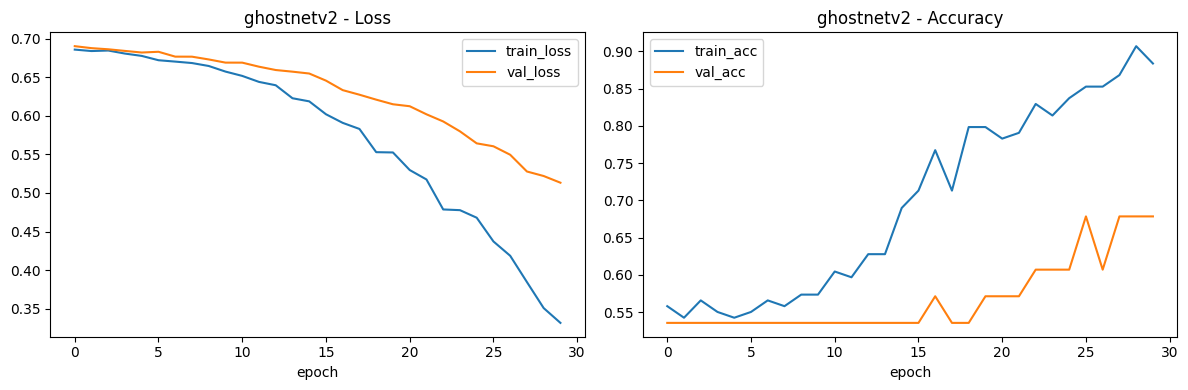

In [20]:
# Cell 20: Loss / accuracy curves from training log
log_path = os.path.join(logger.log_dir, "metrics.csv")
metrics_df = pd.read_csv(log_path)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for cols, ax, title in [(["train_loss","val_loss"], axes[0], "Loss"), (["train_acc","val_acc"], axes[1], "Accuracy")]:
    for c in cols:
        if c in metrics_df.columns:
            sub = metrics_df.dropna(subset=[c])
            ax.plot(sub["epoch"], sub[c], label=c)
    ax.set_title(f"{Config.MODEL_KEY} - {title}"); ax.set_xlabel("epoch"); ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "figures", "training_curves.png"), dpi=150)
plt.show()

In [21]:
# Cell 21: Save everything - predictions CSV, metrics CSV, summary.json, master comparison row
pred_df = test_df.reset_index(drop=True).copy()
pred_df["y_true"] = y_true_test
pred_df["y_pred"] = y_pred_test
pred_df["y_prob"] = y_probs_test
pred_df.to_csv(os.path.join(MODEL_DIR, "predictions.csv"), index=False)

per_model_df = pd.DataFrame({"train": train_metrics, "val": val_metrics, "test": test_metrics}).T
per_model_df.to_csv(os.path.join(MODEL_DIR, "metrics.csv"))

with open(os.path.join(MODEL_DIR, "summary.json"), "w") as f:
    json.dump({
        "model_key": Config.MODEL_KEY, "backbone": Config.BACKBONE,
        "threshold": Config.THRESHOLD, "checkpoint": best_ckpt_path,
        "num_params": num_params, "training_time_sec": training_time_sec,
        "train": train_metrics, "val": val_metrics, "test": test_metrics,
    }, f, indent=2)

master_path = os.path.join(Config.RESULTS_ROOT, "master_comparison.csv")
row = {
    "model": Config.MODEL_KEY, "backbone": Config.BACKBONE, "threshold": Config.THRESHOLD,
    "num_params": num_params, "training_time_min": round(training_time_sec / 60, 2),
    "train_accuracy": train_metrics["accuracy"], "val_accuracy": val_metrics["accuracy"],
    "test_accuracy": test_metrics["accuracy"], "precision": test_metrics["precision"],
    "recall_sensitivity": test_metrics["recall_sensitivity"], "specificity": test_metrics["specificity"],
    "f1_score": test_metrics["f1_score"], "roc_auc": test_metrics["roc_auc"], "pr_auc": test_metrics["pr_auc"],
    "balanced_accuracy": test_metrics["balanced_accuracy"], "mcc": test_metrics["mcc"],
    "cohens_kappa": test_metrics["cohens_kappa"],
    "neo_accuracy": test_metrics.get("neo_accuracy"), "retcam_accuracy": test_metrics.get("retcam_accuracy"),
    "avg_inference_time_sec_per_image": test_metrics["avg_inference_time_sec_per_image"],
    "confusion_matrix": test_metrics["confusion_matrix"], "checkpoint_path": best_ckpt_path,
}

if os.path.exists(master_path):
    master_df = pd.read_csv(master_path)
    master_df = master_df[master_df["model"] != Config.MODEL_KEY]
    master_df = pd.concat([master_df, pd.DataFrame([row])], ignore_index=True)
else:
    master_df = pd.DataFrame([row])

master_df.to_csv(master_path, index=False)
print(f"\nSaved: {MODEL_DIR}/  (checkpoint, predictions.csv, metrics.csv, summary.json, figures/)")
print(f"Appended to: {master_path}")
master_df


Saved: results/ghostnetv2/  (checkpoint, predictions.csv, metrics.csv, summary.json, figures/)
Appended to: results/master_comparison.csv


,model,backbone,num_params,training_time_min,train_accuracy,val_accuracy,test_accuracy,precision,recall_sensitivity,specificity,...,balanced_accuracy,mcc,cohens_kappa,neo_accuracy,retcam_accuracy,avg_inference_time_sec_per_image,confusion_matrix,checkpoint_path,threshold,pr_auc
0,resnet18,resnet18,11242305,2.94,0.565891,0.642857,0.607143,0.600000,0.461538,0.733333,...,0.597436,0.202829,0.197917,0.571429,0.642857,0.000978,"[[11, 4], [7, 6]]",/teamspace/studios/this_studio/results/resnet1...,NaN,NaN
1,se_gem_ghostnetv2,ghostnetv2_100.in1k,5370430,2.90,0.751938,0.642857,0.571429,0.555556,0.384615,0.733333,...,0.558974,0.125954,0.120419,0.857143,0.285714,0.002614,"[[11, 4], [8, 5]]",/teamspace/studios/this_studio/results/se_gem_...,NaN,NaN
2,densenet121,densenet121,7085185,3.42,0.945736,0.928571,0.785714,0.818182,0.692308,0.866667,...,0.779487,0.570806,0.564767,0.785714,0.785714,0.003343,"[[13, 2], [4, 9]]",/teamspace/studios/this_studio/results/densene...,NaN,NaN
3,convnextv2_tiny,convnextv2_tiny.fcmae_ft_in22k_in1k,27965057,3.81,0.992248,0.928571,0.928571,0.923077,0.923077,0.933333,...,0.928205,0.856410,0.856410,0.928571,0.928571,0.004255,"[[14, 1], [1, 12]]",/teamspace/studios/this_studio/results/convnex...,NaN,NaN
4,ghostnetv2,ghostnetv2_100.in1k,5040005,9.67,0.868217,0.678571,0.857143,0.909091,0.769231,0.933333,...,0.851282,0.717435,0.709845,0.857143,0.857143,0.027395,"[[14, 1], [3, 10]]",/teamspace/studios/this_studio/results/ghostne...,0.5,0.892085


In [22]:
# Cell 22: Per-camera performance breakdown (bias check)
test_df_reset = test_df.reset_index(drop=True).copy()
test_df_reset["pred"] = y_pred_test
test_df_reset["prob"] = y_probs_test

for cam in ["Neo", "RetCam"]:
    sub = test_df_reset[test_df_reset["camera"] == cam]
    if len(sub) > 0:
        acc = (sub["pred"] == sub["label"]).mean()
        print(f"{cam}: n={len(sub)}, accuracy={acc:.4f}")

Neo: n=14, accuracy=0.8571
RetCam: n=14, accuracy=0.8571


## Section 15 — Confusion Matrix

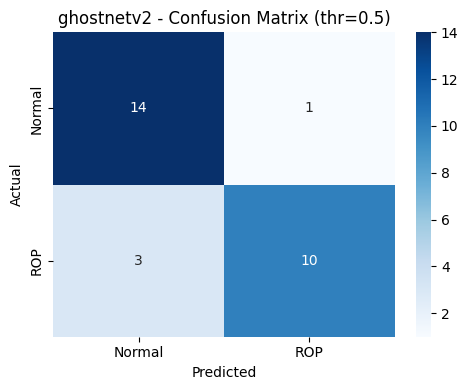

In [23]:
# Cell 23: Confusion matrix (threshold = Config.THRESHOLD, same as everywhere else)
cm = np.array(test_metrics["confusion_matrix"])
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal","ROP"], yticklabels=["Normal","ROP"], ax=ax)
ax.set_title(f"{Config.MODEL_KEY} - Confusion Matrix (thr={Config.THRESHOLD})")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "figures", "confusion_matrix.png"), dpi=150)
plt.show()

## Section 16 — ROC / PR Curve

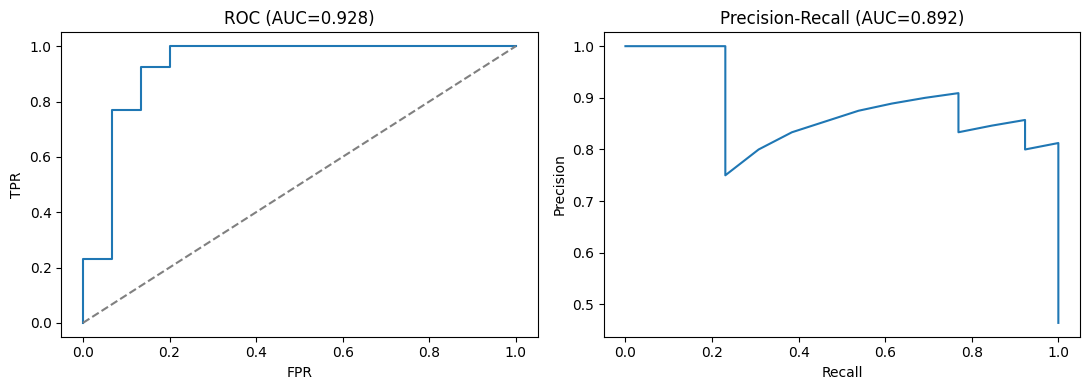

In [24]:
# Cell 24: ROC + Precision-Recall curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fpr, tpr, _ = roc_curve(y_true_test, y_probs_test)
axes[0].plot(fpr, tpr); axes[0].plot([0,1],[0,1],'--',color='gray')
axes[0].set_title(f"ROC (AUC={test_metrics['roc_auc']:.3f})"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")

prec, rec, _ = precision_recall_curve(y_true_test, y_probs_test)
axes[1].plot(rec, prec); axes[1].set_title(f"Precision-Recall (AUC={test_metrics['pr_auc']:.3f})"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.savefig(os.path.join(MODEL_DIR, "figures", "roc_pr_curves.png"), dpi=150)
plt.show()

## Section 17 — Grad-CAM

In [25]:
# Cell 25: Grad-CAM - generic via timm's forward_features/forward_head convention.
# Verified to work unmodified across all 5 registered backbones: each returns a 4D
# (B, C, H, W) spatial map from forward_features() and a pooled (B, feat_dim) vector
# from forward_head(feats, pre_logits=True), so no architecture-specific branching
# is required (confirmed for resnet18, densenet121, tf_efficientnetv2_s, convnext_tiny,
# ghostnetv2_100).
def generate_gradcam(model, image_tensor):
    """image_tensor: single preprocessed image, shape (1,3,H,W)."""
    model.eval()
    image_tensor = image_tensor.to(device).requires_grad_(False)

    backbone = model.model.backbone
    head = model.model.head

    feats = backbone.forward_features(image_tensor)
    feats.retain_grad()
    pooled = backbone.forward_head(feats, pre_logits=True)
    logit = head(pooled).squeeze(1)

    model.zero_grad()
    logit.backward()

    gradients = feats.grad[0]
    activations = feats[0].detach()
    weights = gradients.mean(dim=(1, 2))

    cam = torch.relu((weights[:, None, None] * activations).sum(0))
    cam = cam.cpu().numpy()
    cam = cv2.resize(cam, (Config.IMG_SIZE, Config.IMG_SIZE))
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    return cam, torch.sigmoid(logit).item()

def overlay_heatmap(image_pil, cam):
    img = np.array(image_pil.resize((Config.IMG_SIZE, Config.IMG_SIZE))).astype(np.float32) / 255.0
    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET).astype(np.float32) / 255.0
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = 0.55 * img + 0.45 * heatmap
    return np.clip(overlay, 0, 1)

def plot_gradcam(img_pil, model, threshold=Config.THRESHOLD, title_prefix=""):
    """Shows Input Image | GradCAM Overlay, with Prediction + Confidence in the title."""
    tensor = eval_tf(img_pil).unsqueeze(0)
    cam, prob = generate_gradcam(model, tensor)
    pred_label = "ROP" if prob > threshold else "Normal"
    overlay = overlay_heatmap(img_pil, cam)

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(img_pil.resize((Config.IMG_SIZE, Config.IMG_SIZE)))
    axes[0].set_title("Input Image"); axes[0].axis("off")
    axes[1].imshow(overlay)
    axes[1].set_title(f"{title_prefix}Prediction: {pred_label} | Confidence: {prob:.3f}")
    axes[1].axis("off")
    plt.tight_layout()
    plt.show()
    return pred_label, prob

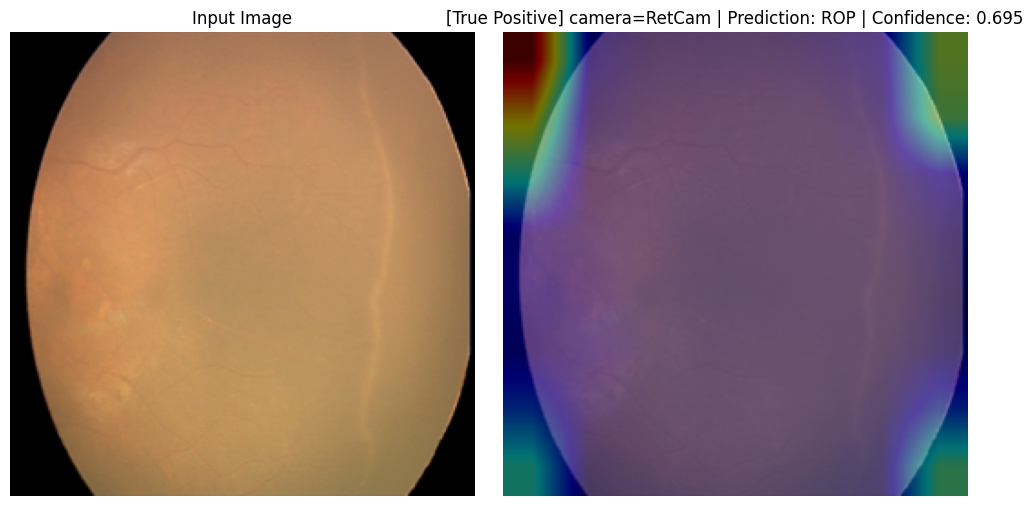

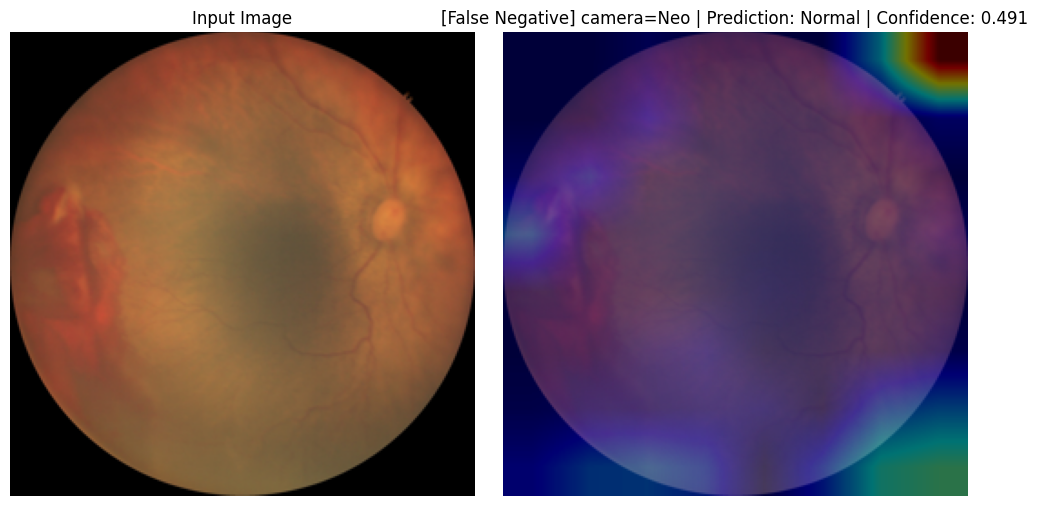

In [26]:

pred_df_check = test_df.reset_index(drop=True).copy()
pred_df_check["y_true"] = y_true_test
pred_df_check["y_pred"] = y_pred_test
pred_df_check["y_prob"] = y_probs_test

true_positive = pred_df_check[(pred_df_check.y_true == 1) & (pred_df_check.y_pred == 1)].sort_values("y_prob", ascending=False).head(1)
false_negative = pred_df_check[(pred_df_check.y_true == 1) & (pred_df_check.y_pred == 0)].head(1)

for label, subset in [("True Positive", true_positive), ("False Negative", false_negative)]:
    if len(subset):
        row = subset.iloc[0]
        img_pil = Image.open(row["filepath"]).convert("RGB")
        plot_gradcam(img_pil, eval_model, title_prefix=f"[{label}] camera={row['camera']} | ")

## Section 18 — External Demo

In [27]:

def risk_band(prob):
    for lo, hi, label in Config.RISK_BANDS:
        if lo <= prob < hi:
            return label
    return "Unknown"

def predict_external_image(image_path, model=None, camera=None,
                            threshold=Config.THRESHOLD, show_gradcam=True):
    if model is None:
        model = eval_model

    img_pil = Image.open(image_path).convert("RGB")
    processed = preprocess_retinal_image(img_pil)
    tensor = eval_tf(processed).unsqueeze(0).to(device)

    model.eval()
    if device.type == "cuda": torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        logit = model(tensor)
        prob = torch.sigmoid(logit).item()
    if device.type == "cuda": torch.cuda.synchronize()
    inference_time_ms = (time.perf_counter() - t0) * 1000

    pred_label = "ROP" if prob > threshold else "Normal"
    camera_label = camera if camera in ("Neo", "RetCam") else "Not specified"

    print(f"Image:               {image_path}")
    print(f"Prediction:          {pred_label}")
    print(f"Confidence Score:    {prob:.4f}")
    print(f"ROP Risk Score:      {risk_band(prob)}")
    print(f"Camera Prediction:   {camera_label}")
    print(f"Inference Time:      {inference_time_ms:.2f} ms")

    if show_gradcam:
        plot_gradcam(img_pil, model, threshold=threshold)

    return {
        "prediction": pred_label, "confidence_score": prob, "rop_risk_score": risk_band(prob),
        "camera_prediction": camera_label, "inference_time_ms": inference_time_ms,
    }

# Usage - update the path (and camera, if known) for your new image
# predict_external_image("/teamspace/studios/this_studio/rop_testing.jpg", camera=None)

## Section 19 — Cross-Model Comparison
Run this section **after** all 5 `MODEL_KEY` values (`resnet18`, `densenet121`, `efficientnetv2_s`,
`convnext_tiny`, `ghostnetv2`) have each been trained once through Section 10 (each run appends /
overwrites its own row in `results/master_comparison.csv` — see Cell 21). This section does not
train anything; it only reads that accumulated file and formats the final report.

In [2]:
# Cell 28: Load master_comparison.csv and check which of the 5 baselines have been run
import os
import pandas as pd
master_path = os.path.join(Config.RESULTS_ROOT, "master_comparison.csv")
assert os.path.exists(master_path), (
    f"{master_path} not found - train at least one MODEL_KEY through Section 10/Cell 21 first."
)
master_df = pd.read_csv(master_path)

expected = list(MODEL_REGISTRY.keys())
present = master_df["model"].tolist()
missing = [m for m in expected if m not in present]

print(f"Models found in master_comparison.csv: {present}")
if missing:
    print(f"NOT YET RUN (set MODEL_KEY to each of these and re-run the notebook): {missing}")
else:
    print("All 5 baselines present.")

NameError: name 'Config' is not defined

In [4]:
# Cell 29: Build the final comparison table with every requested metric,
# ordered and renamed for a clean, exam/report-ready export.
COMPARISON_COLUMNS = [
    ("model",                              "Model"),
    ("backbone",                           "Backbone (timm id)"),
    ("test_accuracy",                      "Accuracy"),
    ("precision",                          "Precision"),
    ("recall_sensitivity",                 "Recall / Sensitivity"),
    ("specificity",                        "Specificity"),
    ("f1_score",                           "F1-Score"),
    ("roc_auc",                            "ROC-AUC"),
    ("pr_auc",                             "PR-AUC"),
    ("mcc",                                "MCC"),
    ("balanced_accuracy",                  "Balanced Accuracy"),
    ("neo_accuracy",                       "Neo Accuracy"),
    ("retcam_accuracy",                    "RetCam Accuracy"),
    ("num_params",                         "Parameter Count"),
    ("training_time_min",                  "Training Time (min)"),
]

comparison_df = master_df[[c for c, _ in COMPARISON_COLUMNS]].copy()
# Recover missing model names from the backbone IDs
backbone_to_model = {
    "resnet18": "resnet18",
    "ghostnetv2_100.in1k": "ghostnetv2",
    "densenet121": "densenet121",
    "convnextv2_tiny.fcmae_ft_in22k_in1k": "convnextv2_tiny",
}

comparison_df["Model"] = comparison_df["Model"].fillna(
    comparison_df["Backbone (timm id)"].map(backbone_to_model)
)
comparison_df.columns = [label for _, label in COMPARISON_COLUMNS]

# order rows to match the 5 requested baselines (only rows that exist so far)
order = [k for k in MODEL_REGISTRY.keys() if k in comparison_df["Model"].values]
comparison_df["Model"] = pd.Categorical(comparison_df["Model"], categories=order, ordered=True)
comparison_df = comparison_df.sort_values("Model").reset_index(drop=True)

# round the numeric metric columns for readability; keep raw values in master_comparison.csv
round_cols = ["Accuracy", "Precision", "Recall / Sensitivity", "Specificity", "F1-Score",
              "ROC-AUC", "PR-AUC", "MCC", "Balanced Accuracy", "Neo Accuracy", "RetCam Accuracy"]
for c in round_cols:
    if c in comparison_df.columns:
        comparison_df[c] = comparison_df[c].astype(float).round(4)
comparison_df["Parameter Count"] = comparison_df["Parameter Count"].map(lambda x: f"{int(x):,}")
comparison_df["Training Time (min)"] = comparison_df["Training Time (min)"].astype(float).round(2)

comparison_out_path = os.path.join(Config.RESULTS_ROOT, "final_comparison_table.csv")
comparison_df.to_csv(comparison_out_path, index=False)
print(f"Saved: {comparison_out_path}")
comparison_df

NameError: name 'master_df' is not defined

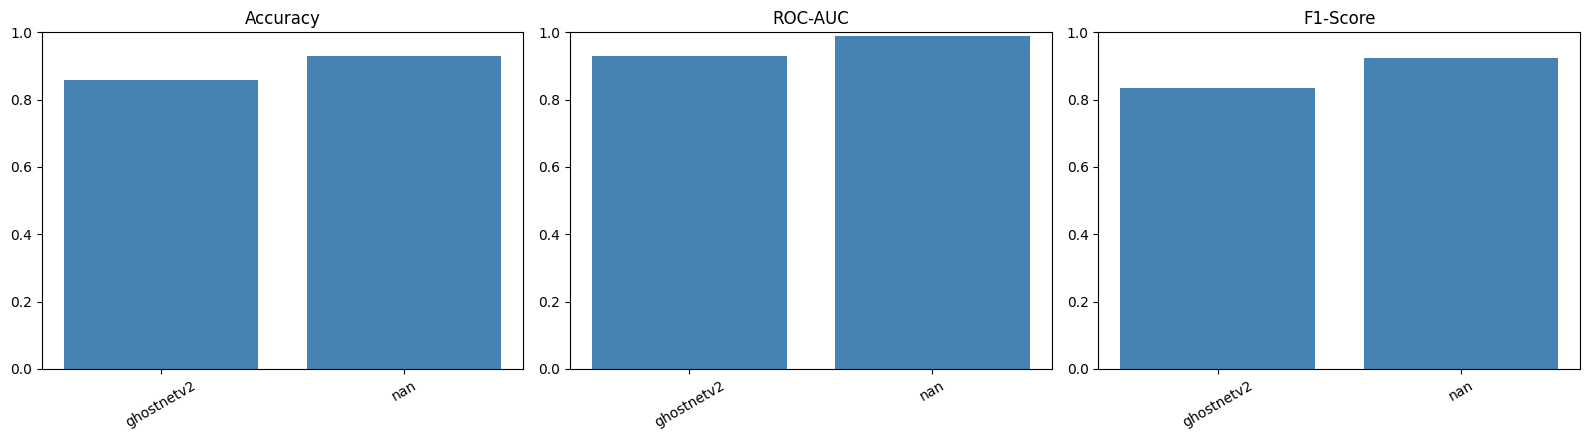

In [30]:
# Cell 30: Bar-chart view of the primary ranking metrics across all trained baselines
if len(comparison_df) > 1:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    for ax, metric in zip(axes, ["Accuracy", "ROC-AUC", "F1-Score"]):
        ax.bar(comparison_df["Model"].astype(str), comparison_df[metric].astype(float), color="steelblue")
        ax.set_title(metric); ax.set_ylim(0, 1); ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.RESULTS_ROOT, "figures_cross_model_comparison.png"), dpi=150)
    plt.show()
else:
    print("Only one model trained so far - bar chart needs at least 2 rows in master_comparison.csv.")